In [7]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import pairwise_distances_argmin_min

# Ativar a atualizacao automatica de modulos externos
%load_ext autoreload
%autoreload 2

# Importar as funcoes que estao guardadas dentro de my_clustering_functions.py
from my_clustering_functions import (
    load_local_data,
    run_kmeans,
    elbow_and_silhouette,
    visualize_umap,
    visualize_pca_clusters,
    plot_linkage_dendrogram
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
# Carregamento dos dados a partir da pasta datasets mapeada
info_clustering = load_local_data("info_clustering_ready.csv")

# Definir o ID do cliente como o indice formal do DataFrame
if 'customer_id' in info_clustering.columns:
    info_clustering.set_index('customer_id', inplace=True)

# CORREÇÃO: Nomes exatos das colunas estruturais e binarias presentes no ficheiro
excluded_cols = ['is_male', 'latitude', 'longitude', 'customer_loyalty_flag']

# Criar a copia dedicada para a fase do K-Means
info_clustering_kmeans = info_clustering.copy()

K=2: Inertia=580501, Silhouette=0.2240
K=3: Inertia=455333, Silhouette=0.2548
K=4: Inertia=408158, Silhouette=0.2605
K=5: Inertia=342486, Silhouette=0.2736
K=6: Inertia=312115, Silhouette=0.2843
K=7: Inertia=300893, Silhouette=0.1925
K=8: Inertia=295220, Silhouette=0.1806
K=9: Inertia=283974, Silhouette=0.1779
K=10: Inertia=277599, Silhouette=0.1800


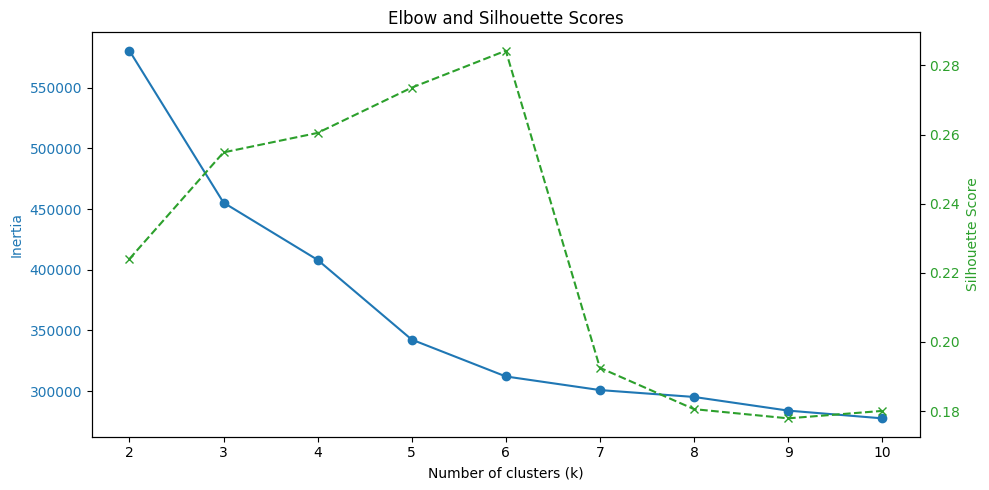

In [13]:
inertias, silhouettes = elbow_and_silhouette(info_clustering_kmeans, exclude_cols=excluded_cols, max_k=10)

In [15]:
k_values = range(2, 11)

results_k = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": silhouettes
})

display(results_k)

,k,inertia,silhouette
0,2,580501.258533,0.224011
1,3,455332.801022,0.254838
2,4,408158.128654,0.260472
3,5,342486.119465,0.273571
4,6,312115.420956,0.284253
5,7,300893.034629,0.192516
6,8,295219.846535,0.180557
7,9,283973.906247,0.177895
8,10,277599.312387,0.180046


In [16]:
best_row = results_k[results_k["k"] >= 3].sort_values(
    "silhouette",
    ascending=False
).iloc[0]

best_k = int(best_row["k"])

print("Best K:", best_k)
print("Best Silhouette:", round(best_row["silhouette"], 4))

Best K: 6
Best Silhouette: 0.2843


In [17]:
labels, centroids, score = run_kmeans(
    info_clustering_kmeans,
    k=best_k,
    exclude_cols=excluded_cols
)

info_clustering["kmeans_cluster"] = labels

print(f"KMeans Silhouette Score: {score:.4f}")

KMeans Silhouette Score: 0.1560


In [18]:
info_clustering["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    13476
1     2408
2     3305
3     2083
4     5043
5     5571
Name: count, dtype: int64

In [19]:
info_clustering["kmeans_cluster"].value_counts(normalize=True).sort_index() * 100

kmeans_cluster
0    42.263062
1     7.551904
2    10.365050
3     6.532648
4    15.815718
5    17.471618
Name: proportion, dtype: float64

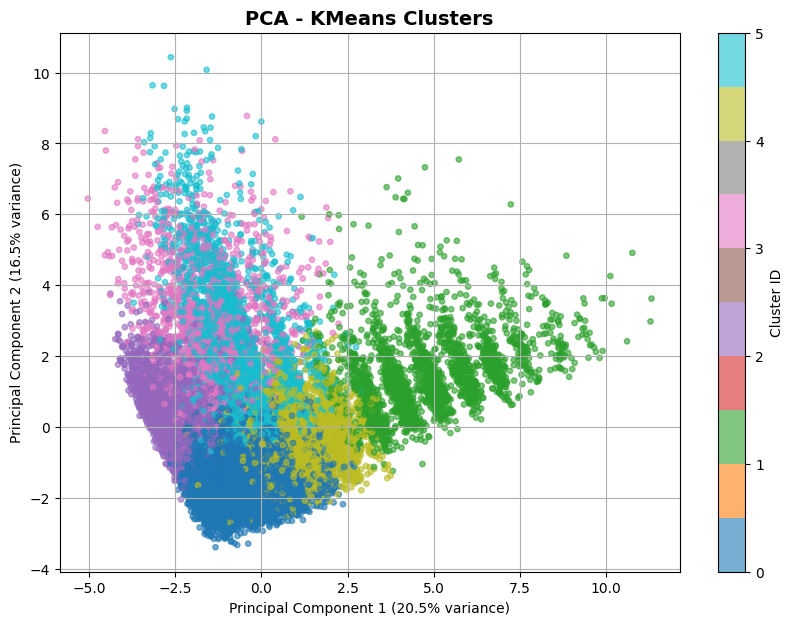

In [20]:
visualize_pca_clusters(
    info_clustering_kmeans,
    exclude_cols=excluded_cols,
    labels=info_clustering["kmeans_cluster"],
    title="PCA - KMeans Clusters"
)

In [21]:
cluster_profile = (
    info_clustering
    .groupby("kmeans_cluster")
    .mean(numeric_only=True)
)

display(cluster_profile)

,customer_id.1,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,...,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,is_male,customer_loyalty_flag
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.001808,-0.371327,0.279905,0.243162,0.412805,0.019747,0.079040,0.041241,0.235200,0.073546,...,0.104015,-0.227228,-0.137412,0.062961,0.009170,0.002519,-0.010991,-0.155055,0.496141,0.654720
1,-0.018604,-0.122924,0.130399,1.274645,-0.129176,-0.005739,0.010744,0.302579,-0.417342,0.098746,...,0.033663,0.257196,0.681667,0.346679,0.481064,-0.132696,-0.340849,0.579239,0.512874,0.677741
2,0.004266,0.026021,-0.744629,-0.113788,0.063197,-0.017904,-0.428786,-0.353549,1.072896,0.027706,...,-0.279481,0.375328,0.965311,0.303918,0.533145,-0.502503,-0.093482,3.184198,0.472315,0.469894
3,0.005191,-0.081133,0.387182,0.208370,0.601049,0.040029,0.008949,-0.011331,0.146357,0.109293,...,0.704916,1.364040,0.862979,2.222682,1.637964,1.308640,2.104140,0.616962,0.491599,0.672588
4,0.021433,0.960539,-0.163692,0.024394,0.575641,0.008270,-0.008688,0.223939,-0.201595,-0.318108,...,-0.047210,-0.082381,0.479145,0.220675,0.278356,-0.021245,0.139877,0.036021,0.504065,0.514773
5,-0.008370,-0.357027,0.202657,-0.134082,-0.332562,0.213011,0.424390,0.032587,-0.155627,0.086991,...,2.175769,1.042706,-0.054865,-0.743918,-0.571124,1.733723,0.597799,0.208542,0.509603,0.583737


In [22]:
overall_mean = info_clustering.drop(
    columns=["kmeans_cluster"],
    errors="ignore"
).mean(numeric_only=True)

cluster_profile_indexed = cluster_profile.div(overall_mean, axis=1)

display(cluster_profile_indexed)

,customer_id.1,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,...,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,is_male,customer_loyalty_flag
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,-3.349837,4.683594,3.263273,1.341381,1.695567,0.418406,1.252007,0.937177,1.815119,5.472563,...,0.238426,-1.030282,-0.636083,0.468399,0.062504,0.007774,-0.049078,-0.396872,0.995780,1.084093
1,-34.476051,1.550452,1.520253,7.031461,-0.530582,-0.121605,0.170187,6.875942,-3.220769,7.347725,...,0.077162,1.166163,3.155443,2.579103,3.279068,-0.409558,-1.521997,1.482595,1.029363,1.122212
2,7.906081,-0.328209,-8.681262,-0.627703,0.259578,-0.379365,-6.792065,-8.034206,8.279892,2.061598,...,-0.640632,1.701787,4.468431,2.260985,3.634063,-1.550949,-0.417428,8.150130,0.947959,0.778057
3,9.619193,1.023341,4.513961,1.149455,2.468763,0.848149,0.141753,-0.257483,1.129487,8.132548,...,1.615819,6.184744,3.994738,16.535557,11.164822,4.039049,9.395641,1.579148,0.986663,1.113680
4,39.717565,-12.115411,-1.908406,0.134570,2.364403,0.175226,-0.137618,5.088900,-1.555779,-23.670512,...,-0.108215,-0.373525,2.217965,1.641706,1.897355,-0.065572,0.624593,0.092197,1.011684,0.852368
5,-15.511635,4.503235,2.362672,-0.739652,-1.365974,4.513343,6.722430,0.740512,-1.201024,6.473010,...,4.987333,4.727773,-0.253969,-5.534352,-3.892938,5.351047,2.669359,0.533774,1.022799,0.966560


In [23]:
cols_to_ignore = [
    "latitude",
    "longitude"
]

profile_clean = cluster_profile_indexed.drop(
    columns=cols_to_ignore,
    errors="ignore"
)

for cluster in profile_clean.index:
    print(f"\nCluster {cluster} - Above average")
    display(profile_clean.loc[cluster].sort_values(ascending=False).head(8))

    print(f"Cluster {cluster} - Below average")
    display(profile_clean.loc[cluster].sort_values(ascending=True).head(8))


Cluster 0 - Above average


tenure                                     11.000495
customer_age                                5.472563
number_complaints                           4.683594
distinct_stores_visited                     3.263273
typical_hour_cos                            1.815119
percentage_of_products_bought_promotion     1.695567
lifetime_total_distinct_products            1.341381
education_level                             1.119298
Name: 0, dtype: float64

Cluster 0 - Below average


total_children                -141.680170
customer_id.1                   -3.349837
pct_spend_groceries             -1.270568
pct_spend_nonalcohol_drinks     -1.030282
pct_spend_alcohol_drinks        -0.636083
pct_spend_technology            -0.396872
pct_spend_petfood               -0.049078
pct_spend_hygiene                0.007774
Name: 0, dtype: float64


Cluster 1 - Above average


...

customer_age                  -23.670512
tenure                        -15.495488
number_complaints             -12.115411
distinct_stores_visited        -1.908406
typical_hour_cos               -1.555779
pct_spend_nonalcohol_drinks    -0.373525
pct_spend_groceries            -0.313177
pct_spend_vegetables           -0.108215
Name: 4, dtype: float64


Cluster 5 - Above average


customer_age                   6.473010
pct_spend_hygiene              5.351047
pct_spend_vegetables           4.987333
pct_spend_nonalcohol_drinks    4.727773
number_complaints              4.503235
pct_spend_petfood              2.669359
pct_spend_groceries            2.463732
distinct_stores_visited        2.362672
Name: 5, dtype: float64

Cluster 5 - Below average


total_children                            -18.833634
customer_id.1                             -15.511635
tenure                                     -6.959538
pct_spend_meat                             -5.534352
pct_spend_fish                             -3.892938
percentage_of_products_bought_promotion    -1.365974
typical_hour_cos                           -1.201024
lifetime_total_distinct_products           -0.739652
Name: 5, dtype: float64

In [24]:
labels20, centroids20, score20 = run_kmeans(
    info_clustering_kmeans,
    k=20,
    exclude_cols=excluded_cols
)

info_clustering["kmeans20_cluster"] = labels20

print(f"KMeans 20 Silhouette Score: {score20:.4f}")

KMeans 20 Silhouette Score: 0.1248


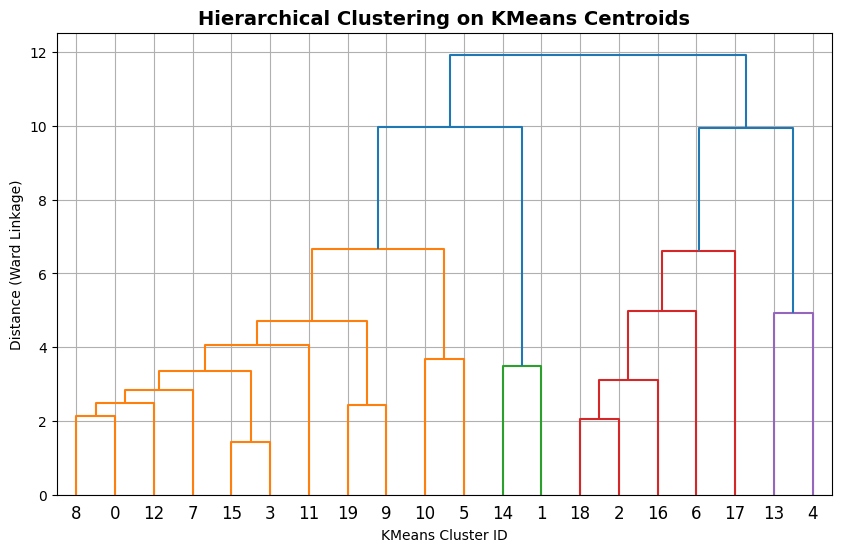

In [25]:
linked = plot_linkage_dendrogram(
    centroids20,
    title="Hierarchical Clustering on KMeans Centroids"
)